# LARGE-SCALE NLP PIPELINE FOR LEGAL DOCUMENT ANALYSIS

## Muc tieu de tai

Xay dung he thong xu ly ngon ngu tu nhien QUY MO LON (Large-scale) cho van ban phap luat Viet Nam gom:

1. Kham pha du lieu quy mo lon (498,938 van ban)
2. Pipeline tien xu ly hieu qua voi batch processing
3. Xay dung mo hinh phan loai (Machine Learning vs Deep Learning)
4. PHAN TICH TOAN DIEN van ban phap luat:
   - Trich xuat cau truc phap ly (dieu, khoan, muc)
   - Phan tich chu de (Topic Modeling)
   - Tim kiem van ban tuong tu
   - Trich xuat tu khoa phap ly
5. Danh gia hieu nang he thong (throughput, memory, scalability)
6. So sanh hieu suat cac phuong phap

## Phuong phap tiep can

### A. Xu ly du lieu quy mo lon
- Batch processing de xu ly hang tram ngan van ban
- Memory optimization va garbage collection
- Parallel processing khi co the
- Incremental learning cho Deep Learning

### B. Phan loai van ban

1. **Machine Learning truyen thong (TF-IDF + Logistic Regression)**
   - Uu diem: Nhanh, don gian, hieu qua
   - Phu hop: He thong can toc do cao

2. **Deep Learning (CNN + Embeddings)**
   - Uu diem: Trích xuất đặc trưng tốt, training nhanh, hiệu quả với văn bản
   - Phu hop: Ung dung can do chinh xac cao va toc do inference tot

### C. Phan tich van ban phap luat
- Trich xuat cau truc (dieu, khoan, diem)
- Topic modeling voi LDA
- Document similarity voi cosine
- Keyword extraction
- Network analysis (neu co tham chieu)

## 1. Kham pha du lieu (Exploratory Data Analysis)

Phan nay se thuc hien:
- Doc du lieu tu file CSV da tao
- Phan tich phan bo cac loai van ban
- Kiem tra do dai van ban
- Phan tich tu vung va dac trung ngon ngu
- Truc quan hoa phan bo du lieu

In [1]:
# Cai dat cac thu vien can thiet
# Chay cau lenh nay neu chua cai dat tren Kaggle
!pip install underthesea -q
!pip install wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.6 MB/s eta 0:00:00


In [2]:
# Import các thư viện cơ bản
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import gc
import warnings
from pathlib import Path
from tqdm import tqdm
from collections import Counter

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# Thư viện xử lý tiếng Việt
from underthesea import word_tokenize

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_recall_fscore_support, ConfusionMatrixDisplay)
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# WordCloud
from wordcloud import WordCloud

print("Đã import thành công tất cả thư viện!")

2025-12-24 11:19:20.719189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766575161.208954      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766575161.324707      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766575162.441990      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766575162.442031      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766575162.442034      24 computation_placer.cc:177] computation placer alr

Đã import thành công tất cả thư viện!


In [3]:
# Doc du lieu tu file CSV
DATA_PATH = Path("/kaggle/input/bigdata-cuoiky/top5_documents.csv")

df = pd.read_csv(DATA_PATH)

print(f"Tong so ban ghi: {len(df):,}")
print(f"So cot: {len(df.columns)}")
print(f"\nCac cot trong du lieu:")
print(df.columns.tolist())
print(f"\nThong tin du lieu:")
df.info()

Tong so ban ghi: 498,938
So cot: 9

Cac cot trong du lieu:
['id', 'ministry', 'type', 'name', 'chapter_id', 'chapter_name', 'article', 'content', 'type_normalized']

Thong tin du lieu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498938 entries, 0 to 498937
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               498588 non-null  object
 1   ministry         498329 non-null  object
 2   type             498938 non-null  object
 3   name             498925 non-null  object
 4   chapter_id       498935 non-null  object
 5   chapter_name     498938 non-null  object
 6   article          498905 non-null  object
 7   content          410121 non-null  object
 8   type_normalized  498938 non-null  object
dtypes: object(9)
memory usage: 34.3+ MB


In [4]:
# Hien thi mau du lieu
print("Mau 5 ban ghi dau tien:")
display(df.head())

print("\nMau 5 ban ghi ngau nhien:")
display(df.sample(5, random_state=42))

Mau 5 ban ghi dau tien:


,id,ministry,type,name,chapter_id,chapter_name,article,content,type_normalized
0,02/2014/TT-BNNPTTN,BỘ NÔNG NGHIỆP VÀ PHÁT TRIỂN NÔNG THÔN,THÔNG TƯ,"QUY ĐỊNH TRÌNH TỰ, THỦ TỤC CẤP VÀ THU HỒI GIẤY...",Chương I,QUY ĐỊNH CHUNG,Điều 1. Phạm vi điều chỉnh,"Thông tư này quy định trình tự, thủ tục cấp và...",THÔNG TƯ
1,02/2014/TT-BNNPTTN,BỘ NÔNG NGHIỆP VÀ PHÁT TRIỂN NÔNG THÔN,THÔNG TƯ,"QUY ĐỊNH TRÌNH TỰ, THỦ TỤC CẤP VÀ THU HỒI GIẤY...",Chương I,QUY ĐỊNH CHUNG,Điều 2. Đối tượng áp dụng,"Thông tư này áp dụng đối với các tổ chức, cá n...",THÔNG TƯ
2,02/2014/TT-BNNPTTN,BỘ NÔNG NGHIỆP VÀ PHÁT TRIỂN NÔNG THÔN,THÔNG TƯ,"QUY ĐỊNH TRÌNH TỰ, THỦ TỤC CẤP VÀ THU HỒI GIẤY...",Chương I,QUY ĐỊNH CHUNG,Điều 3. Giải thích từ ngữ,Trong Thông tư này các từ ngữ dưới đây được hi...,THÔNG TƯ
3,02/2014/TT-BNNPTTN,BỘ NÔNG NGHIỆP VÀ PHÁT TRIỂN NÔNG THÔN,THÔNG TƯ,"QUY ĐỊNH TRÌNH TỰ, THỦ TỤC CẤP VÀ THU HỒI GIẤY...",Chương I,QUY ĐỊNH CHUNG,Điều 4. Tiêu chí đánh giá rủi ro đối với thực ...,1. So sánh về thành phần dinh dưỡng của thực v...,THÔNG TƯ
4,02/2014/TT-BNNPTTN,BỘ NÔNG NGHIỆP VÀ PHÁT TRIỂN NÔNG THÔN,THÔNG TƯ,"QUY ĐỊNH TRÌNH TỰ, THỦ TỤC CẤP VÀ THU HỒI GIẤY...",Chương II,CẤP VÀ THU HỒI GIẤY XÁC NHẬN,Điều 5. Các trường hợp phải đăng ký cấp Giấy x...,1. Thực vật biến đổi gen mang sự kiện chuyển g...,THÔNG TƯ



Mau 5 ban ghi ngau nhien:


,id,ministry,type,name,chapter_id,chapter_name,article,content,type_normalized
59769,73/2015/NĐ-CP,CHÍNH PHỦ,NGHỊ ĐỊNH,"QUY ĐỊNH TIÊU CHUẨN PHÂN TẦNG, KHUNG XẾP HẠNG ...",Chương III,"KHUNG XẾP HẠNG, TIÊU CHUẨN XẾP HẠNG CƠ SỞ GIÁO...",Điều 7. Tiêu chuẩn xếp hạng cơ sở giáo dục đại...,"1. Quy mô, ngành nghề và các trình độ đào tạo ...",NGHỊ ĐỊNH
483383,01/2005/TT-BTC,BỘ TÀI CHÍNH,THÔNG TƯ,CỦA BỘ TÀI CHÍNH SỐ 01/2005/TT-BTC NGÀY 04 THÁ...,none,none,1. Mức thu:,Căn cứ quy định tại Điều 13 và Điều 14 Nghị đị...,THÔNG TƯ
480332,03/2007/TT-NHNN,NaN,THÔNG TƯ,GUIDING THE IMPLEMENTATION OF SEVERAL ARTICLES...,none,Phần II,39. Ngân hàng Nhà nước huỷ bỏ biện pháp phong ...,a) Ngân hàng mẹ và/hoặc chi nhánh ngân hàng nư...,THÔNG TƯ
374085,29/2019/TT-BNNPTNT,BỘ NÔNG NGHIỆP VÀ PHÁT TRIỂN NÔNG THÔN,THÔNG TƯ,"QUY ĐỊNH XỬ LÝ ĐỘNG VẬT RỪNG LÀ TANG VẬT, VẬT ...",Chương I,QUY ĐỊNH CHUNG,Điều 3. Giải thích từ ngữ,1. Động vật rừng quy định tại Thông tư này bao...,THÔNG TƯ
228710,743/QĐ-UBND,ỦY BAN NHÂN DÂN THÀNH PHỐ CẦN THƠ,QUYẾT ĐỊNH,VỀ VIỆC BAN HÀNH ĐIỀU LỆ TỔ CHỨC VÀ HOẠT ĐỘNG ...,Chương V,"MỐI QUAN HỆ VÀ TRÁCH NHIỆM CỦA CÁC CƠ QUAN, TỔ...",Điều 41. Trách nhiệm của Sở Lao động - Thương ...,1. Thực hiện chức năng quản lý nhà nước về quả...,QUYẾT ĐỊNH


In [5]:
# Phan tich phan bo cac loai van ban
label_counts = df['type_normalized'].value_counts()
label_percentages = (label_counts / len(df) * 100).round(2)

print("Phan bo cac loai van ban:")
print("="*60)
for label, count in label_counts.items():
    pct = label_percentages[label]
    print(f"{label:20s}: {count:8,} van ban ({pct:5.2f}%)")

print("="*60)
print(f"Tong cong: {len(df):,} van ban")

Phan bo cac loai van ban:
THÔNG TƯ            :  147,670 van ban (29.60%)
QUYẾT ĐỊNH          :  138,951 van ban (27.85%)
NGHỊ QUYẾT          :   96,826 van ban (19.41%)
NGHỊ ĐỊNH           :   82,882 van ban (16.61%)
LUẬT                :   32,609 van ban ( 6.54%)
Tong cong: 498,938 van ban


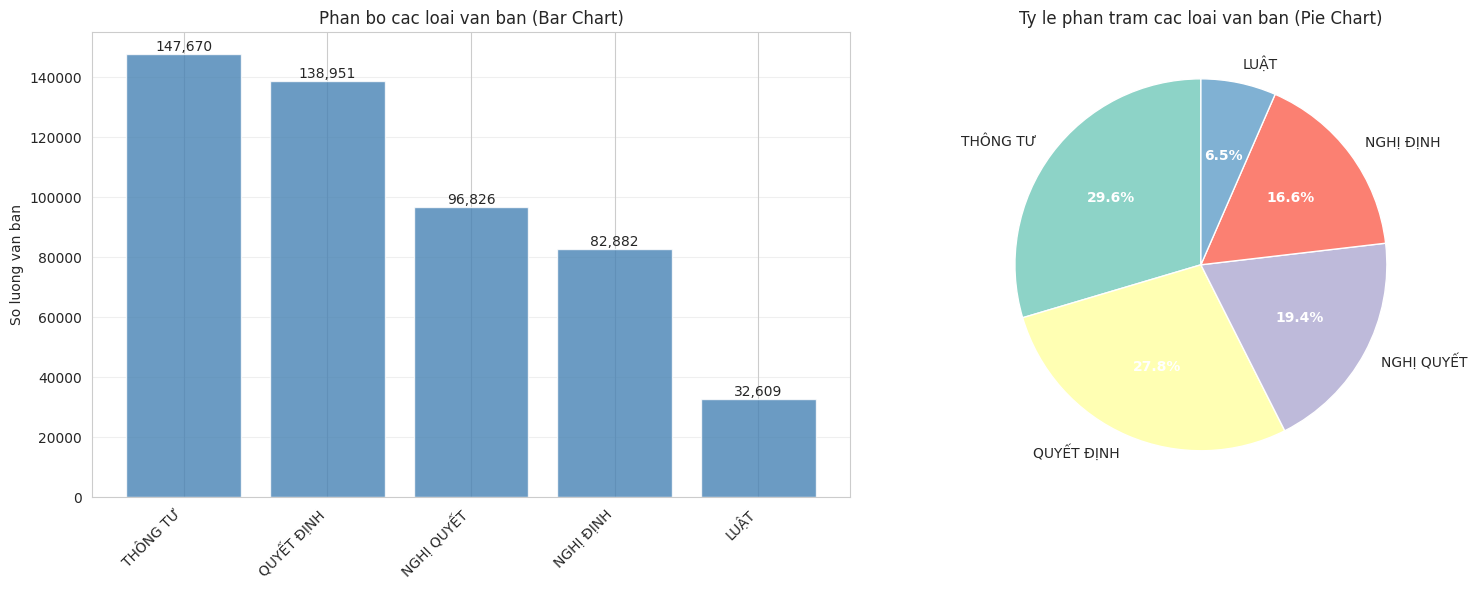

In [6]:
# Truc quan hoa phan bo cac loai van ban
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bieu do cot
axes[0].bar(range(len(label_counts)), label_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(label_counts.index, rotation=45, ha='right')
axes[0].set_ylabel('So luong van ban')
axes[0].set_title('Phan bo cac loai van ban (Bar Chart)')
axes[0].grid(axis='y', alpha=0.3)

# Them gia tri len cot
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Bieu do tron
colors = plt.cm.Set3(range(len(label_counts)))
wedges, texts, autotexts = axes[1].pie(
    label_counts.values, 
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[1].set_title('Ty le phan tram cac loai van ban (Pie Chart)')

# Lam dep chu trong bieu do tron
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

plt.tight_layout()
plt.show()

In [7]:
# Phan tich do dai noi dung van ban
df['content_length'] = df['content'].astype(str).str.len()
df['word_count'] = df['content'].astype(str).str.split().str.len()

print("Thong ke do dai noi dung van ban:")
print("="*60)
print(df[['content_length', 'word_count']].describe())

print("\nThong ke theo tung loai van ban:")
print("="*60)
stats_by_type = df.groupby('type_normalized')[['content_length', 'word_count']].agg(['mean', 'median', 'std'])
print(stats_by_type)

Thong ke do dai noi dung van ban:
       content_length     word_count
count   498938.000000  498938.000000
mean      1296.947557     283.657605
std       3389.246701     736.297242
min          1.000000       1.000000
25%        184.000000      40.000000
50%        584.000000     129.000000
75%       1337.000000     294.000000
max     371980.000000   80540.000000

Thong ke theo tung loai van ban:
                content_length                      word_count         \
                          mean median          std        mean median   
type_normalized                                                         
LUẬT                849.833298  600.0  2344.953450  188.653562  133.0   
NGHỊ QUYẾT         1294.443600  393.0  3074.410558  280.994340   86.0   
NGHỊ ĐỊNH          1166.999964  716.0  2129.485250  257.327888  159.0   
QUYẾT ĐỊNH         1311.200258  410.0  3243.626956  284.626199   90.0   
THÔNG TƯ           1456.846563  734.0  4344.587853  320.249550  162.0   

              

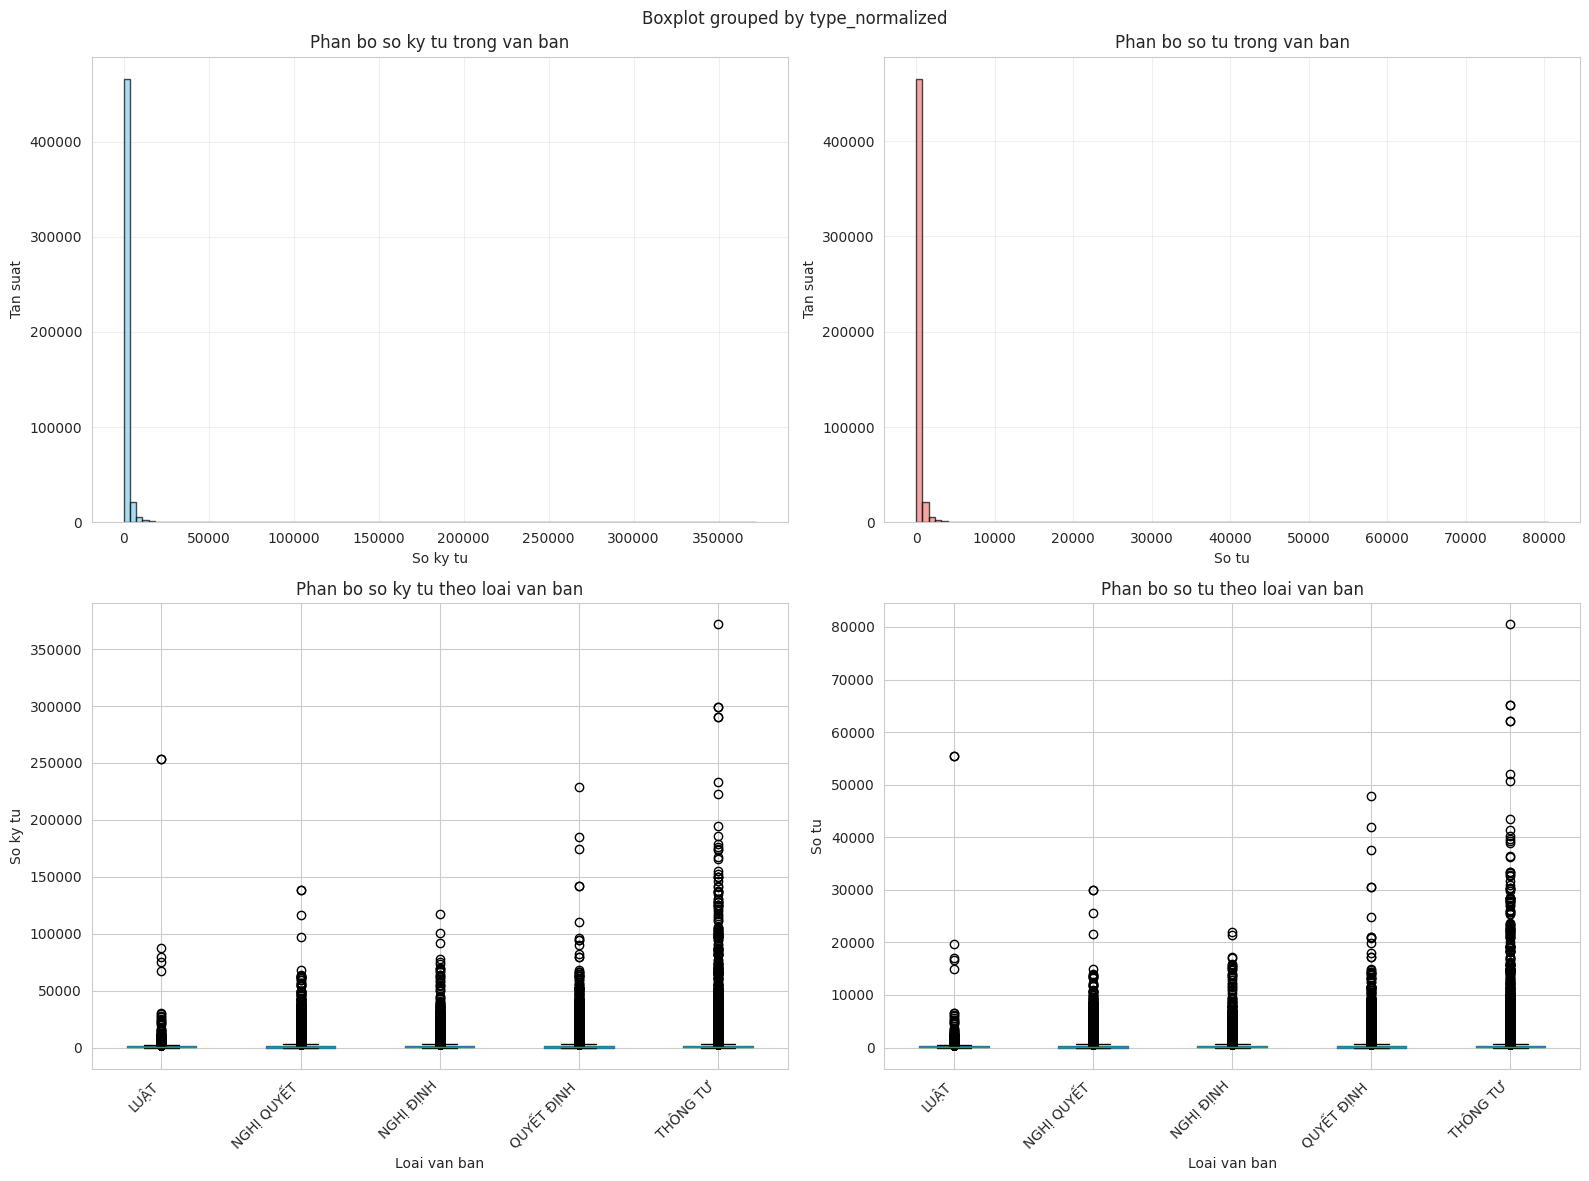

In [8]:
# Truc quan hoa phan bo do dai van ban
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram so ky tu
axes[0, 0].hist(df['content_length'], bins=100, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('So ky tu')
axes[0, 0].set_ylabel('Tan suat')
axes[0, 0].set_title('Phan bo so ky tu trong van ban')
axes[0, 0].grid(alpha=0.3)

# Histogram so tu
axes[0, 1].hist(df['word_count'], bins=100, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('So tu')
axes[0, 1].set_ylabel('Tan suat')
axes[0, 1].set_title('Phan bo so tu trong van ban')
axes[0, 1].grid(alpha=0.3)

# Boxplot so ky tu theo loai van ban
df.boxplot(column='content_length', by='type_normalized', ax=axes[1, 0])
axes[1, 0].set_xlabel('Loai van ban')
axes[1, 0].set_ylabel('So ky tu')
axes[1, 0].set_title('Phan bo so ky tu theo loai van ban')
axes[1, 0].tick_params(axis='x', rotation=45)
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# Boxplot so tu theo loai van ban
df.boxplot(column='word_count', by='type_normalized', ax=axes[1, 1])
axes[1, 1].set_xlabel('Loai van ban')
axes[1, 1].set_ylabel('So tu')
axes[1, 1].set_title('Phan bo so tu theo loai van ban')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.sca(axes[1, 1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 2. Tien xu ly du lieu (Text Preprocessing)

Cac buoc tien xu ly:
1. Lam sach van ban (loai bo ky tu dac biet, so)
2. Chuan hoa chu hoa/thuong
3. Tach tu (word segmentation) cho tieng Viet
4. Loai bo stopwords
5. Tao tap train/validation/test

In [9]:
# Danh sach stopwords tieng Viet cho van ban phap luat
VIETNAMESE_STOPWORDS = set([
    'bị', 'bởi', 'cả', 'các', 'cái', 'cần', 'càng', 'chỉ', 'chiếc', 'cho', 'chứ', 
    'chưa', 'chuyện', 'có', 'có_thể', 'cứ', 'của', 'cùng', 'cũng', 'đã', 'đang', 
    'đây', 'để', 'đến_nỗi', 'đều', 'điều', 'do', 'đó', 'được', 'dưới', 'gì', 
    'khi', 'không', 'là', 'lại', 'lên', 'lúc', 'mà', 'mỗi', 'một_cách', 'này', 
    'nên', 'nếu', 'ngay', 'nhiều', 'như', 'nhưng', 'những', 'nơi', 'nữa', 'phải', 
    'qua', 'ra', 'rằng', 'rất', 'rồi', 'sau', 'sẽ', 'so', 'sự', 'tại', 'theo', 
    'thì', 'trên', 'trước', 'từ', 'từng', 'và', 'vẫn', 'vào', 'vậy', 'với', 'vừa'
])

print(f"So luong stopwords: {len(VIETNAMESE_STOPWORDS)}")

So luong stopwords: 73


In [10]:
def preprocess_text(text, use_word_segmentation=True, remove_stopwords=True):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    if use_word_segmentation:
        try:
            text = word_tokenize(text, format="text")
        except:
            pass
    
    if remove_stopwords:
        words = text.split()
        words = [w for w in words if w not in VIETNAMESE_STOPWORDS]
        text = ' '.join(words)
    
    return text

# Test hàm
sample_text = "Điều 1. Phạm vi điều chỉnh và đối tượng áp dụng"
print("Ví dụ tiền xử lý:")
print(preprocess_text(sample_text))

Ví dụ tiền xử lý:
phạm_vi điều_chỉnh đối_tượng áp_dụng


In [11]:
# Batch processing toàn bộ dữ liệu
BATCH_SIZE = 10000
total_batches = (len(df) + BATCH_SIZE - 1) // BATCH_SIZE
all_processed = []

print(f"\nBắt đầu tiền xử lý {len(df):,} văn bản (batch size = {BATCH_SIZE})")
for i in tqdm(range(total_batches), desc="Processing batches"):
    start_idx = i * BATCH_SIZE
    end_idx = min((i + 1) * BATCH_SIZE, len(df))
    batch = df.iloc[start_idx:end_idx].copy()
    batch['content_processed'] = batch['content'].apply(
        lambda x: preprocess_text(x, use_word_segmentation=True, remove_stopwords=True)
    )
    all_processed.append(batch[['id', 'type_normalized', 'content', 'content_processed']])
    del batch
    gc.collect()

df_processed = pd.concat(all_processed, ignore_index=True)
df_processed = df_processed[df_processed['content_processed'].str.len() > 10].copy()
print(f"Hoàn thành! Còn lại {len(df_processed):,} văn bản sau lọc.")


Bắt đầu tiền xử lý 498,938 văn bản (batch size = 10000)


Processing batches: 100%|██████████| 50/50 [2:51:50<00:00, 206.21s/it]


Hoàn thành! Còn lại 409,655 văn bản sau lọc.


In [12]:
# Chia dữ liệu thành tập train, validation, test
# Sử dụng TOÀN BỘ dữ liệu đã xử lý

X = df_processed['content_processed'].values
y = df_processed['type_normalized'].values

print(f"Tổng số mẫu: {len(X):,}")
print(f"Phân bố nhãn:")
for label, count in pd.Series(y).value_counts().items():
    print(f"  {label:20s}: {count:6,} ({count/len(y)*100:5.2f}%)")

# Chia 70% train, 15% validation, 15% test
print("\nĐang chia dữ liệu...")
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 * 0.85 ≈ 0.15
)

print("\nKích thước các tập dữ liệu:")
print("="*60)
print(f"Train:      {len(X_train):8,} mẫu ({len(X_train)/len(X)*100:5.2f}%)")
print(f"Validation: {len(X_val):8,} mẫu ({len(X_val)/len(X)*100:5.2f}%)")
print(f"Test:       {len(X_test):8,} mẫu ({len(X_test)/len(X)*100:5.2f}%)")
print(f"Tổng:       {len(X):8,} mẫu")

# Lưu dữ liệu đã xử lý trực tiếp vào output Kaggle
print("\nLưu dữ liệu đã xử lý vào output Kaggle...")
np.savez_compressed(
    '/kaggle/working/processed_data.npz',  # Lưu thẳng vào /kaggle/working/
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test
)

print("Đã lưu thành công file: /kaggle/working/processed_data.npz")


Tổng số mẫu: 409,655
Phân bố nhãn:
  THÔNG TƯ            : 137,324 (33.52%)
  QUYẾT ĐỊNH          : 96,619 (23.59%)
  NGHỊ ĐỊNH           : 75,124 (18.34%)
  NGHỊ QUYẾT          : 68,767 (16.79%)
  LUẬT                : 31,821 ( 7.77%)

Đang chia dữ liệu...

Kích thước các tập dữ liệu:
Train:       286,921 mẫu (70.04%)
Validation:   61,285 mẫu (14.96%)
Test:         61,449 mẫu (15.00%)
Tổng:        409,655 mẫu

Lưu dữ liệu đã xử lý vào output Kaggle...
Đã lưu thành công file: /kaggle/working/processed_data.npz


## 3. Xay dung mo hinh Machine Learning truyen thong (TF-IDF + Logistic Regression)

Phuong phap TF-IDF (Term Frequency-Inverse Document Frequency):
- Bieu dien van ban thanh vector dac trung
- TF: Tan suat xuat hien cua tu trong van ban
- IDF: Ty trong cua tu trong toan bo tap du lieu
- Logistic Regression: Mo hinh phan loai tuyen tinh don gian nhung hieu qua

In [13]:
print("\nHuấn luyện TF-IDF + Logistic Regression...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000, min_df=2, max_df=0.8, ngram_range=(1,2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
start = time.time()
lr_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start
print(f"Thời gian huấn luyện: {training_time:.2f}s")


Huấn luyện TF-IDF + Logistic Regression...
Thời gian huấn luyện: 74.62s


In [14]:
# Đánh giá validation
start = time.time()
y_val_pred = lr_model.predict(X_val_tfidf)
val_inference_time = time.time() - start

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='weighted')

print(f"\nKết quả Validation (TF-IDF + LR):")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-Score : {val_f1:.4f}")
print(f"Inference: {val_inference_time:.3f}s → {len(y_val)/val_inference_time:.1f} văn bản/giây")


Kết quả Validation (TF-IDF + LR):
Accuracy : 0.8467
Precision: 0.8465
Recall   : 0.8467
F1-Score : 0.8463
Inference: 0.035s → 1772463.1 văn bản/giây


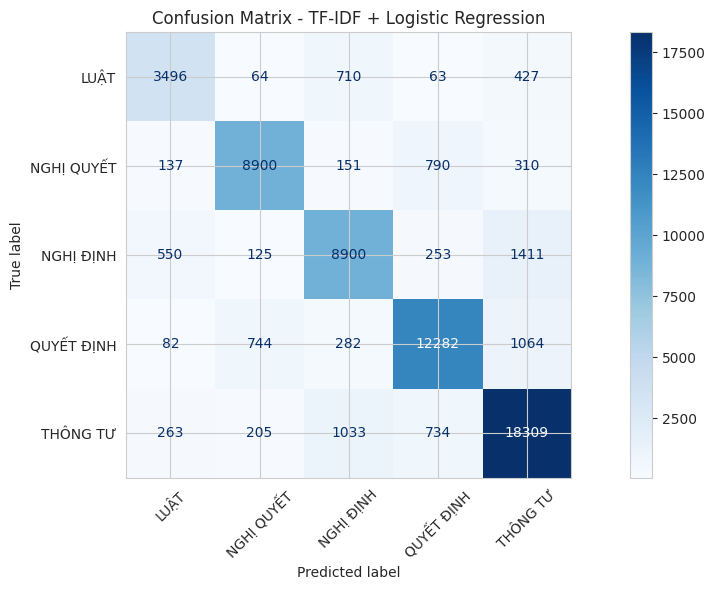

In [15]:
# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - TF-IDF + Logistic Regression')
plt.tight_layout()
plt.show()

## 4. Xay dung mo hinh Deep Learning (CNN + Embeddings)

Phuong phap Deep Learning voi CNN:
- Embeddings: Bieu dien tu thanh vector (word embeddings)
- CNN (Convolutional Neural Network): Trích xuất đặc trưng cục bộ từ văn bản
- Uu diem: 
  + Nhanh hơn RNN/LSTM trong training và inference
  + Trích xuất đặc trưng n-gram tự động
  + Hiệu quả với văn bản phân loại
  + Song song hóa tốt trên GPU

In [16]:
print("\nChuẩn bị dữ liệu cho CNN...")
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train_enc, num_classes)
y_val_cat   = to_categorical(y_val_enc,   num_classes)


Chuẩn bị dữ liệu cho CNN...


In [17]:
# Xây dựng mô hình CNN với kiến trúc tối ưu
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, MaxPooling1D, Concatenate, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Model

print("\n" + "="*70)
print("XÂY DỰNG MÔ HÌNH CNN TỐI ƯU (Multi-Channel CNN)")
print("="*70)

# Tăng embedding dimension cho representation tốt hơn
EMBEDDING_DIM = 256

# Input
input_layer = Input(shape=(MAX_LEN,))

# Embedding layer với dimension lớn hơn
embedding = Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_LEN)(input_layer)
embedding = Dropout(0.3)(embedding)

# Multi-channel CNN với nhiều kernel sizes khác nhau (như trong TextCNN paper)
# Channel 1: kernel size 3 (trigrams)
conv1 = Conv1D(256, 3, activation='relu', padding='valid')(embedding)
conv1 = BatchNormalization()(conv1)
pool1 = GlobalMaxPooling1D()(conv1)

# Channel 2: kernel size 4 (4-grams)
conv2 = Conv1D(256, 4, activation='relu', padding='valid')(embedding)
conv2 = BatchNormalization()(conv2)
pool2 = GlobalMaxPooling1D()(conv2)

# Channel 3: kernel size 5 (5-grams)
conv3 = Conv1D(256, 5, activation='relu', padding='valid')(embedding)
conv3 = BatchNormalization()(conv3)
pool3 = GlobalMaxPooling1D()(conv3)

# Concatenate các channels
concat = Concatenate()([pool1, pool2, pool3])
concat = Dropout(0.4)(concat)

# Fully connected layers với BatchNormalization
dense1 = Dense(256, activation='relu')(concat)
dense1 = BatchNormalization()(dense1)
dense1 = Dropout(0.5)(dense1)

dense2 = Dense(128, activation='relu')(dense1)
dense2 = BatchNormalization()(dense2)
dense2 = Dropout(0.4)(dense2)

# Output layer
output = Dense(num_classes, activation='softmax')(dense2)

# Tạo model
model = Model(inputs=input_layer, outputs=output)

# Compile với learning rate tối ưu
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nKiến trúc Multi-Channel CNN:")
print("- 3 kênh song song (kernel sizes: 3, 4, 5)")
print("- Embedding dimension: 256")
print("- BatchNormalization sau mỗi layer")
print("- Dropout được điều chỉnh tối ưu")
model.summary()


XÂY DỰNG MÔ HÌNH CNN TỐI ƯU (Multi-Channel CNN)


I0000 00:00:1766585949.947856      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766585949.951705      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Kiến trúc Multi-Channel CNN:
- 3 kênh song song (kernel sizes: 3, 4, 5)
- Embedding dimension: 256
- BatchNormalization sau mỗi layer
- Dropout được điều chỉnh tối ưu


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 256)  │  5,120,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 200, 256)  │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 198, 256)  │    196,864 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 197, 256)  │    262,400 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 196, 256)  │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 198, 256)  │      1,024 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 197, 256)  │      1,024 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 196, 256)  │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 768)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    196,864 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 6,142,213 (23.43 MB)

 Trainable params: 6,139,909 (23.42 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [18]:
# Callbacks được tối ưu cho CNN
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        'best_cnn_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("\n" + "="*70)
print("BẮT ĐẦU HUẤN LUYỆN CNN")
print("="*70)
print(f"Training samples: {len(X_train_pad):,}")
print(f"Validation samples: {len(X_val_pad):,}")
print(f"Batch size: 32")
print(f"Max epochs: 30 (với early stopping)")
print("="*70)

# Huấn luyện
start = time.time()
history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)
dl_training_time = time.time() - start

print("\n" + "="*70)
print(f"HOÀN THÀNH HUẤN LUYỆN CNN: {dl_training_time:.2f}s")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Số epochs thực tế: {len(history.history['loss'])}")
print("="*70)


BẮT ĐẦU HUẤN LUYỆN CNN
Training samples: 286,921
Validation samples: 61,285
Batch size: 32
Max epochs: 30 (với early stopping)
Epoch 1/50


I0000 00:00:1766585958.393276      98 service.cc:152] XLA service 0x7ad1e4002640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766585958.393306      98 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766585958.393310      98 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766585959.356296      98 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1766585966.592342      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_accuracy improved from -inf to 0.80206, saving model to best_cnn_model.h5


8967/8967 - 137s - 15ms/step - accuracy: 0.7168 - loss: 0.7325 - val_accuracy: 0.8021 - val_loss: 0.5069 - learning_rate: 1.0000e-03
Epoch 2/50

Epoch 2: val_accuracy improved from 0.80206 to 0.82317, saving model to best_cnn_model.h5


8967/8967 - 121s - 14ms/step - accuracy: 0.7846 - loss: 0.5594 - val_accuracy: 0.8232 - val_loss: 0.4541 - learning_rate: 1.0000e-03
Epoch 3/50

Epoch 3: val_accuracy improved from 0.82317 to 0.83366, saving model to best_cnn_model.h5


...

8967/8967 - 119s - 13ms/step - accuracy: 0.9186 - loss: 0.2224 - val_accuracy: 0.8836 - val_loss: 0.3318 - learning_rate: 2.5000e-04
Epoch 38/50

Epoch 38: val_accuracy did not improve from 0.88361
8967/8967 - 119s - 13ms/step - accuracy: 0.9193 - loss: 0.2213 - val_accuracy: 0.8829 - val_loss: 0.3313 - learning_rate: 2.5000e-04
Epoch 39/50

Epoch 39: val_accuracy improved from 0.88361 to 0.88416, saving model to best_cnn_model.h5


8967/8967 - 119s - 13ms/step - accuracy: 0.9197 - loss: 0.2183 - val_accuracy: 0.8842 - val_loss: 0.3297 - learning_rate: 2.5000e-04
Epoch 40/50

Epoch 40: val_accuracy improved from 0.88416 to 0.88495, saving model to best_cnn_model.h5


8967/8967 - 119s - 13ms/step - accuracy: 0.9204 - loss: 0.2175 - val_accuracy: 0.8849 - val_loss: 0.3290 - learning_rate: 2.5000e-04
Epoch 41/50

Epoch 41: val_accuracy did not improve from 0.88495
8967/8967 - 119s - 13ms/step - accuracy: 0.9213 - loss: 0.2140 - val_accuracy: 0.8840 - val_loss: 0.3323 - learning_rate: 2.5000e-04
Epoch 42/50

Epoch 42: val_accuracy did not improve from 0.88495
8967/8967 - 119s - 13ms/step - accuracy: 0.9224 - loss: 0.2132 - val_accuracy: 0.8841 - val_loss: 0.3317 - learning_rate: 2.5000e-04
Epoch 43/50

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 43: val_accuracy did not improve from 0.88495
8967/8967 - 119s - 13ms/step - accuracy: 0.9224 - loss: 0.2123 - val_accuracy: 0.8840 - val_loss: 0.3322 - learning_rate: 2.5000e-04
Epoch 44/50

Epoch 44: val_accuracy did not improve from 0.88495
8967/8967 - 118s - 13ms/step - accuracy: 0.9241 - loss: 0.2080 - val_accuracy: 0.8839 - val_loss: 0.3322 - learning_rate: 1.2500e-

8967/8967 - 119s - 13ms/step - accuracy: 0.9260 - loss: 0.2018 - val_accuracy: 0.8850 - val_loss: 0.3323 - learning_rate: 6.2500e-05
Epoch 48/50

Epoch 48: val_accuracy did not improve from 0.88500
8967/8967 - 119s - 13ms/step - accuracy: 0.9260 - loss: 0.2008 - val_accuracy: 0.8848 - val_loss: 0.3325 - learning_rate: 6.2500e-05
Epoch 49/50

Epoch 49: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 49: val_accuracy improved from 0.88500 to 0.88524, saving model to best_cnn_model.h5


8967/8967 - 119s - 13ms/step - accuracy: 0.9265 - loss: 0.2022 - val_accuracy: 0.8852 - val_loss: 0.3304 - learning_rate: 6.2500e-05
Epoch 50/50

Epoch 50: val_accuracy did not improve from 0.88524
8967/8967 - 118s - 13ms/step - accuracy: 0.9265 - loss: 0.1999 - val_accuracy: 0.8849 - val_loss: 0.3330 - learning_rate: 3.1250e-05
Restoring model weights from the end of the best epoch: 49.

HOÀN THÀNH HUẤN LUYỆN CNN: 5974.28s
Best val_accuracy: 0.8852
Số epochs thực tế: 50


In [19]:
# Đánh giá validation
start = time.time()
y_val_pred_proba_dl = model.predict(X_val_pad, verbose=0)
y_val_pred_dl = np.argmax(y_val_pred_proba_dl, axis=1)
dl_inference_time = time.time() - start

y_val_pred_labels_dl = label_encoder.inverse_transform(y_val_pred_dl)

dl_val_accuracy = accuracy_score(y_val, y_val_pred_labels_dl)
dl_val_precision, dl_val_recall, dl_val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred_labels_dl, average='weighted')

print(f"\nKết quả Validation (CNN):")
print(f"Accuracy : {dl_val_accuracy:.4f}")
print(f"Precision: {dl_val_precision:.4f}")
print(f"Recall   : {dl_val_recall:.4f}")
print(f"F1-Score : {dl_val_f1:.4f}")
print(f"Inference: {dl_inference_time:.3f}s → {len(y_val)/dl_inference_time:.1f} văn bản/giây")


Kết quả Validation (CNN):
Accuracy : 0.8852
Precision: 0.8854
Recall   : 0.8852
F1-Score : 0.8852
Inference: 9.102s → 6733.1 văn bản/giây


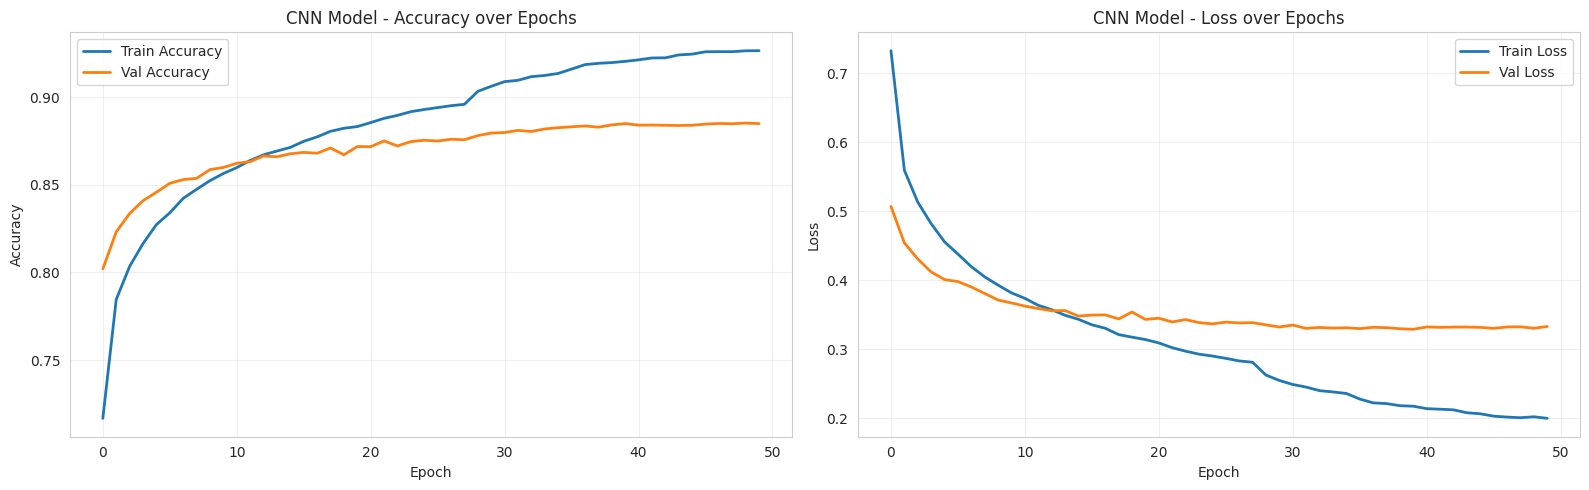


Best Training Accuracy: 0.9265
Best Validation Accuracy: 0.8852
Final Training Loss: 0.1999
Final Validation Loss: 0.3330


In [20]:
# Visualize training history cho CNN
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN Model - Accuracy over Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('CNN Model - Loss over Epochs')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Training Accuracy: {max(history.history['accuracy']):.4f}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

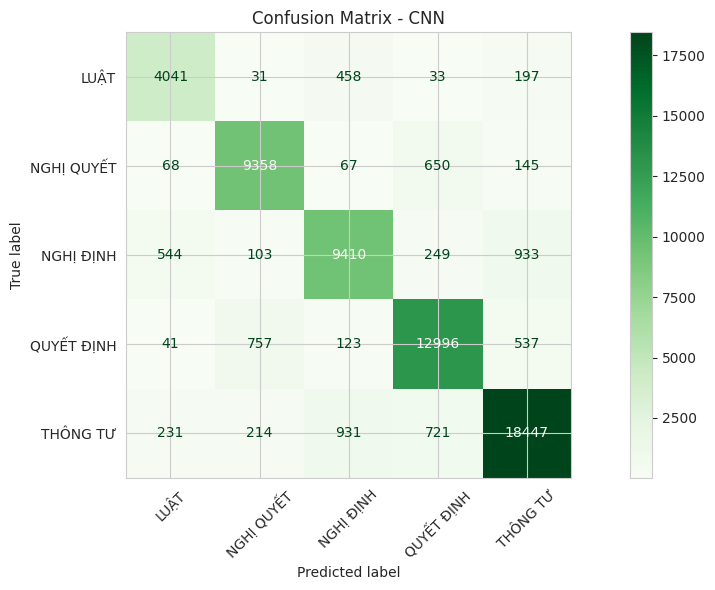

In [21]:
# Confusion matrix CNN
cm_dl = confusion_matrix(y_val, y_val_pred_labels_dl, labels=label_encoder.classes_)
disp_dl = ConfusionMatrixDisplay(confusion_matrix=cm_dl, display_labels=label_encoder.classes_)
disp_dl.plot(cmap='Greens', xticks_rotation=45)
plt.title('Confusion Matrix - CNN')
plt.tight_layout()
plt.show()

## 5. So sanh hieu suat cac mo hinh

Phan nay so sanh chi tiet hieu suat giua hai phuong phap:
- TF-IDF + Logistic Regression (Machine Learning truyen thong)
- CNN + Embeddings (Deep Learning)

So sanh dua tren cac chi tieu:
- Accuracy, Precision, Recall, F1-Score
- Thoi gian huan luyen
- Thoi gian du doan
- Hieu suat tren tung loai van ban

,Metric,TF-IDF + LR,CNN,Difference (%)
0,Accuracy,8.466509e-01,0.885241,4.56
1,Precision,8.464766e-01,0.885383,4.60
2,Recall,8.466509e-01,0.885241,4.56
3,F1-Score,8.463123e-01,0.885238,4.60
4,Training Time (s),7.461795e+01,5974.282677,7906.50
5,Inference Time (s),3.457618e-02,9.102103,26224.78
6,Samples/sec,1.772463e+06,6733.059386,-99.62


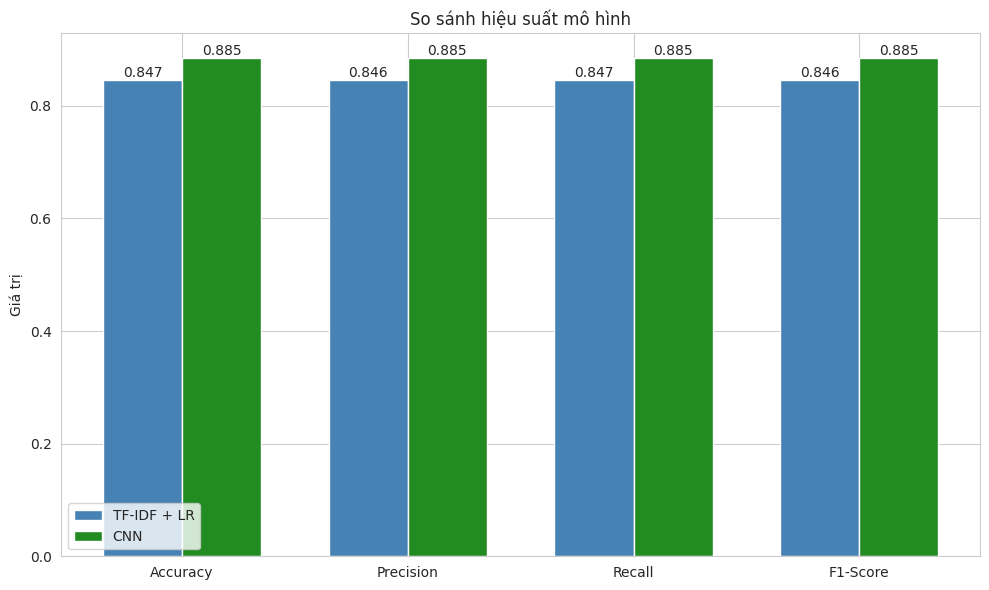


ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET
TF-IDF + LR  → Acc: 0.8463 | F1: 0.8461 | Time: 0.032s
CNN          → Acc: 0.8850 | F1: 0.8850 | Time: 8.328s


In [22]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Inference Time (s)', 'Samples/sec'],
    'TF-IDF + LR': [val_accuracy, val_precision, val_recall, val_f1, training_time, val_inference_time, len(y_val)/val_inference_time],
    'CNN': [dl_val_accuracy, dl_val_precision, dl_val_recall, dl_val_f1, dl_training_time, dl_inference_time, len(y_val)/dl_inference_time]
})
comparison_df['Difference (%)'] = ((comparison_df['CNN'] - comparison_df['TF-IDF + LR']) / comparison_df['TF-IDF + LR'] * 100).round(2)
display(comparison_df)

# Trực quan hóa so sánh
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
tfidf_scores = [val_accuracy, val_precision, val_recall, val_f1]
cnn_scores = [dl_val_accuracy, dl_val_precision, dl_val_recall, dl_val_f1]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, tfidf_scores, width, label='TF-IDF + LR', color='steelblue')
ax.bar(x + width/2, cnn_scores, width, label='CNN', color='forestgreen')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Giá trị')
ax.set_title('So sánh hiệu suất mô hình')
ax.legend()
for i, (t, c) in enumerate(zip(tfidf_scores, cnn_scores)):
    ax.text(i - width/2, t, f'{t:.3f}', ha='center', va='bottom')
    ax.text(i + width/2, c, f'{c:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Đánh giá cuối cùng trên Test set
print("\nĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET")
# TF-IDF + LR
start = time.time()
y_test_pred_lr = lr_model.predict(X_test_tfidf)
test_time_lr = time.time() - start
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)
test_prec_lr, test_rec_lr, test_f1_lr, _ = precision_recall_fscore_support(y_test, y_test_pred_lr, average='weighted')

# CNN
start = time.time()
y_test_pred_proba_dl = model.predict(X_test_pad, verbose=0)
y_test_pred_dl = np.argmax(y_test_pred_proba_dl, axis=1)
test_time_dl = time.time() - start
y_test_pred_labels_dl = label_encoder.inverse_transform(y_test_pred_dl)
test_acc_dl = accuracy_score(y_test, y_test_pred_labels_dl)
test_prec_dl, test_rec_dl, test_f1_dl, _ = precision_recall_fscore_support(y_test, y_test_pred_labels_dl, average='weighted')

print(f"TF-IDF + LR  → Acc: {test_acc_lr:.4f} | F1: {test_f1_lr:.4f} | Time: {test_time_lr:.3f}s")
print(f"CNN          → Acc: {test_acc_dl:.4f} | F1: {test_f1_dl:.4f} | Time: {test_time_dl:.3f}s")

## 6. Phan tich toan dien van ban phap luat (Legal Document Analysis)

Phan nay thuc hien cac phan tich sau tren du lieu quy mo lon:
1. Trich xuat cau truc phap ly (dieu, khoan, muc)
2. Phan tich chu de voi Topic Modeling (LDA)
3. Tim kiem van ban tuong tu (Document Similarity)
4. Trich xuat va phan tich tu khoa phap ly
5. Visualization va insights

In [23]:
# 6.1 Trích xuất cấu trúc pháp lý
def extract_legal_structure(text):
    if pd.isna(text) or not text:
        return {'articles': [], 'clauses': 0, 'points': 0}
    structure = {'articles': [], 'clauses': 0, 'points': 0}
    article_pattern = r'Điều\s+(\d+)[:\.]?\s*([^\n]+)'
    articles = re.findall(article_pattern, str(text), re.IGNORECASE)
    structure['articles'] = [(num, title.strip()[:100]) for num, title in articles]
    structure['clauses'] = len(re.findall(r'^\s*\d+\.\s+', str(text), re.MULTILINE))
    structure['points'] = len(re.findall(r'^\s*[a-z]\)\s+', str(text), re.MULTILINE))
    return structure



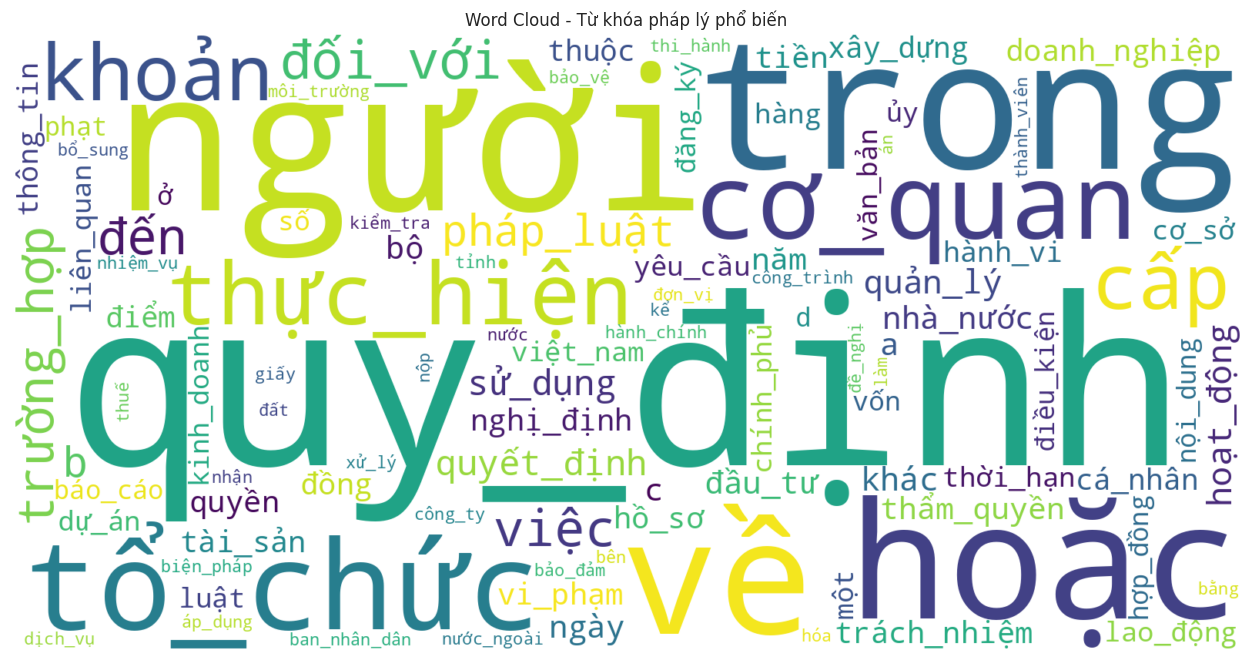

In [24]:
# 6.2 Keyword analysis & WordCloud
sample_keywords = df_processed['content_processed'].head(50000)
all_text = ' '.join(sample_keywords)
word_freq = Counter(all_text.split())
top_keywords = word_freq.most_common(100)

plt.figure(figsize=(16,8))
wordcloud = WordCloud(width=1600, height=800, background_color='white', max_words=100, colormap='viridis').generate_from_frequencies(dict(top_keywords))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Từ khóa pháp lý phổ biến')
plt.show()



In [25]:
# 6.3 Topic Modeling LDA
n_topics = 10
n_samples_lda = 30000
lda_vectorizer = CountVectorizer(max_features=5000, max_df=0.8, min_df=10)
doc_term_matrix = lda_vectorizer.fit_transform(df_processed['content_processed'].head(n_samples_lda))

lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20, learning_method='online', n_jobs=-1)
lda_model.fit(doc_term_matrix)

feature_names = lda_vectorizer.get_feature_names_out()
print("\nCác chủ đề phát hiện bởi LDA:")
for i, topic in enumerate(lda_model.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Chủ đề {i+1}: {', '.join(top_words)}")




Các chủ đề phát hiện bởi LDA:
Chủ đề 1: xây_dựng, đầu_tư, sử_dụng, quy_định, môi_trường, quy_hoạch, dự_án, về, công_trình, đất
Chủ đề 2: người, pháp_luật, quy_định, việc, yêu_cầu, hoặc, cơ_quan, giải_quyết, về, quyền
Chủ đề 3: doanh_nghiệp, công_ty, quy_định, tổ_chức, nhà_nước, vốn, thành_viên, hoặc, khác, hoạt_động
Chủ đề 4: cơ_quan, tổ_chức, cấp, về, thực_hiện, ủy, quốc_hội, bộ, nhiệm_vụ, chính_phủ
Chủ đề 5: người, án, hoặc, đến, năm, thi_hành, phạt, trong, gây, đồng
Chủ đề 6: việt_nam, quy_định, nước_ngoài, đăng_ký, cơ_quan, cấp, quốc_tế, giấy, chứng_nhận, giấy_phép
Chủ đề 7: người, lao_động, quy_định, giáo_dục, cơ_sở, bệnh, tàu, trong, hoặc, đào_tạo
Chủ đề 8: về, tổ_chức, quy_định, thông_tin, trong, hoạt_động, công_nghệ, sản_xuất, sử_dụng, cá_nhân
Chủ đề 9: bên, tài_sản, hợp_đồng, hàng, thuế, quyền, tiền, thuê, người, trường_hợp
Chủ đề 10: ngày, quyết_định, thời_hạn, kể, luật, người, trong, trường_hợp, văn_bản, hội_đồng


In [26]:
# 6.4 Tìm văn bản tương tự
def find_similar_documents(query_text, top_k=5):
    query_processed = preprocess_text(query_text)
    query_vec = tfidf_vectorizer.transform([query_processed])
    similarities = cosine_similarity(query_vec, X_train_tfidf).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    results = []
    for idx in top_indices:
        results.append({
            'similarity': float(similarities[idx]),
            'type': y_train[idx],
            'preview': X_train[idx][:300]
        })
    return results

## 7. Danh gia hieu nang he thong quy mo lon (System Performance)

Danh gia kha nang xu ly va hieu suat cua he thong tren du lieu quy mo lon:
- Throughput (so van ban xu ly duoc/giay)
- Memory usage (su dung bo nho)
- Processing time breakdown
- Scalability analysis

In [27]:
import psutil

def benchmark_system():
    process = psutil.Process()
    memory_mb = process.memory_info().rss / 1024**2
    
    n_benchmark = 1000
    test_sample = df['content'].sample(n=n_benchmark, random_state=42)
    
    # Preprocessing
    start = time.time()
    processed = test_sample.apply(lambda x: preprocess_text(x))
    prep_time = time.time() - start
    prep_throughput = n_benchmark / prep_time
    
    # TF-IDF prediction
    vec = tfidf_vectorizer.transform(processed)
    start = time.time()
    lr_model.predict(vec)
    tfidf_time = time.time() - start
    tfidf_throughput = n_benchmark / tfidf_time
    
    # CNN prediction
    seqs = tokenizer.texts_to_sequences(processed)
    pads = pad_sequences(seqs, maxlen=MAX_LEN)
    start = time.time()
    model.predict(pads, verbose=0)
    dl_time = time.time() - start
    dl_throughput = n_benchmark / dl_time
    
    print(f"Memory usage : {memory_mb:.1f} MB")
    print(f"Preprocessing: {prep_throughput:.1f} văn bản/giây")
    print(f"TF-IDF pred  : {tfidf_throughput:.1f} văn bản/giây")
    print(f"CNN pred     : {dl_throughput:.1f} văn bản/giây")
    print(f"TF-IDF nhanh hơn CNN: {tfidf_throughput/dl_throughput:.1f}x")
    
    return {'prep': prep_throughput, 'tfidf': tfidf_throughput, 'dl': dl_throughput, 'memory': memory_mb}

performance_metrics = benchmark_system()

Memory usage : 8145.2 MB
Preprocessing: 59.4 văn bản/giây
TF-IDF pred  : 1094261.4 văn bản/giây
CNN pred     : 1066.6 văn bản/giây
TF-IDF nhanh hơn CNN: 1025.9x


## 8. Demo ung dung thuc te - He thong phan tich van ban phap luat

Tao ham du doan va phan tich toan dien cho van ban phap luat

In [28]:
# =================================== 8. DEMO ỨNG DỤNG ===================================

def analyze_legal_document(text, use_model='both', find_similar=True):
    analysis = {}
    text_processed = preprocess_text(text)
    
    # Cấu trúc
    structure = extract_legal_structure(text)
    analysis['structure'] = {
        'num_articles': len(structure['articles']),
        'num_clauses': structure['clauses'],
        'num_points': structure['points']
    }
    
    # TF-IDF + LR
    if use_model in ['tfidf', 'both']:
        vec = tfidf_vectorizer.transform([text_processed])
        pred = lr_model.predict(vec)[0]
        proba = lr_model.predict_proba(vec)[0].max()
        analysis['tfidf_lr'] = {'prediction': pred, 'confidence': float(proba)}
    
    # CNN
    if use_model in ['cnn', 'both']:
        seq = tokenizer.texts_to_sequences([text_processed])
        pad = pad_sequences(seq, maxlen=MAX_LEN)
        proba_dl = model.predict(pad, verbose=0)[0]
        pred_idx = np.argmax(proba_dl)
        pred_dl = label_encoder.inverse_transform([pred_idx])[0]
        analysis['cnn'] = {'prediction': pred_dl, 'confidence': float(proba_dl.max())}
    
    # Văn bản tương tự
    if find_similar and use_model in ['tfidf', 'both']:
        analysis['similar'] = find_similar_documents(text, top_k=3)
    
    return analysis

# Demo
sample_texts = [
    """Điều 1. Phạm vi điều chỉnh và đối tượng áp dụng
    1. Luật này quy định về quyền và nghĩa vụ của công dân Việt Nam.
    a) Công dân trong nước;
    b) Công dân ở nước ngoài.""",
    """Quyết định số 123/2023/QĐ-TTg về việc bổ nhiệm cán bộ
    QUYẾT ĐỊNH:
    Điều 1. Bổ nhiệm ông Nguyễn Văn A giữ chức vụ Giám đốc Sở."""
]

for i, text in enumerate(sample_texts, 1):
    print(f"\n=== VĂN BẢN MẪU {i} ===")
    result = analyze_legal_document(text, use_model='both', find_similar=True)
    print("Cấu trúc:", result['structure'])
    if 'tfidf_lr' in result:
        print("TF-IDF + LR →", result['tfidf_lr'])
    if 'cnn' in result:
        print("CNN         →", result['cnn'])
    if 'similar' in result:
        print("\nVăn bản tương tự:")
        for j, doc in enumerate(result['similar'], 1):
            print(f"{j}. [{doc['type']}] (sim={doc['similarity']:.3f}) {doc['preview']}...")


=== VĂN BẢN MẪU 1 ===
Cấu trúc: {'num_articles': 1, 'num_clauses': 1, 'num_points': 2}
TF-IDF + LR → {'prediction': 'LUẬT', 'confidence': 0.9480908146042515}
CNN         → {'prediction': 'LUẬT', 'confidence': 0.9807924628257751}

Văn bản tương tự:
1. [LUẬT] (sim=0.539) người quốc_tịch việt_nam công_dân việt_nam công_dân việt_nam nhà_nước cộng_hòa xã_hội_chủ_nghĩa_việt_nam bảo_đảm quyền_công_dân làm tròn nghĩa_vụ công_dân đối_với nhà_nước xã_hội quy_định pháp_luật nhà_nước cộng_hòa xã_hội_chủ_nghĩa_việt_nam chính_sách công_dân việt_nam ở nước_ngoài điều_kiện hưởng ...
2. [LUẬT] (sim=0.469) ủy ban_nhân_dân cấp huyện cư_trú người nhận cha_mẹ_con thực_hiện đăng_ký nhận cha_mẹ_con giữa công_dân việt_nam người nước_ngoài giữa công_dân việt_nam cư_trú ở trong nước công_dân việt_nam định_cư ở nước_ngoài giữa công_dân việt_nam định_cư ở nước_ngoài nhau giữa công_dân việt_nam đồng_thời quốc_tị...
3. [LUẬT] (sim=0.442) ủy ban_nhân_dân cấp huyện cư_trú công_dân việt_nam thực_hiện đăng_ký kết_hôn 